### Setup
Loading raw tables plus the customer-level table built in the SQL step.

In [1]:
# Standard data manipulation and viz stack
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import sys
from pathlib import Path

# Import our reusable loader instead of re-writing pd.read_csv calls here
sys.path.append("../src")
from load_data import load_raw_tables

sns.set_style("whitegrid")

# Raw tables (needed for the window-function query below)
tables = load_raw_tables()

# Pre-built customer-level table from Step C (one row per real customer)
customer_features = pd.read_csv("../data/processed/customer_features.csv")

2


In [2]:
customer_features.head()

,customer_unique_id,customer_state,n_orders,first_purchase_date,last_purchase_date,recency_days,total_spend,avg_order_value,avg_review_score,avg_delivery_delay_days
0,0a0a92112bd4c708ca5fde585afaa872,RJ,1,2017-09-29 15:24:52,2017-09-29 15:24:52,334,13664.08,13664.080,1.0,-6.0
1,da122df9eeddfedc1dc1f5349a1a690c,RJ,2,2017-04-01 15:58:40,2017-04-01 15:58:41,515,7571.63,3785.815,5.0,-18.5
2,763c8b1c9c68a0229c42c9fc6f662b93,ES,1,2018-07-15 14:49:44,2018-07-15 14:49:44,45,7274.88,7274.880,1.0,-7.0
3,dc4802a71eae9be1dd28f5d788ceb526,MS,1,2017-02-12 20:37:36,2017-02-12 20:37:36,563,6929.31,6929.310,5.0,-6.0
4,459bef486812aa25204be022145caa62,ES,1,2018-07-25 18:10:17,2018-07-25 18:10:17,35,6922.21,6922.210,NaN,5.0


In [3]:
print(len(customer_features))
customer_features.isnull().sum()

93358


customer_unique_id           0
customer_state               0
n_orders                     0
first_purchase_date          0
last_purchase_date           0
recency_days                 0
total_spend                  1
avg_order_value              1
avg_review_score           603
avg_delivery_delay_days      8
dtype: int64

### Repeat purchase rate
Most e-commerce customers here only buy once. Checking the actual rate first, since 
it changes what "churn" even means for this business, it's not "did they cancel," 
it's "will they come back at all."

In [4]:
customer_features.n_orders.value_counts()

n_orders
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64

In [5]:
# This dataset is known to have a very low repeat-purchase rate.
# We check it explicitly because it changes how we should define "churn" later:
# with subscription products, churn = cancellation. Here, most customers were
# never going to buy again regardless of any campaign, so "churn" really means
# "will this customer ever return" rather than "did they leave."
repeat_rate = (customer_features["n_orders"] > 1).mean()
print(f"Repeat purchase rate: {repeat_rate:.2%}")

Repeat purchase rate: 3.00%


## Measuring time between repeat purchases

To set a churn threshold based on evidence rather than a guess, we first need 
to know how much time typically passes between a customer's orders. We use a 
SQL window function (`LAG`) to find each customer's previous order date, then 
compute the gap in days. Only repeat customers are included here, a 
first-time buyer has no prior order to measure against.

In [6]:
# here we wanted to find out how many days typically pass between a customer's orders,
# so we can set a churn threshold based on actual behavior instead of
# guessing a round number.
#
# LAG() looks back to each customer's PREVIOUS order within the same
# customer_unique_id, so we can compute the gap between consecutive purchases.
# We only look at repeat customers here — first-time buyers have no gap to measure.
repeat_query = """
WITH orders_customers AS (
    SELECT
        c.customer_unique_id,
        CAST(o.order_purchase_timestamp AS TIMESTAMP) AS order_purchase_timestamp
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'  -- only count orders that actually completed
),
ranked AS (
    SELECT
        customer_unique_id,
        order_purchase_timestamp,
        LAG(order_purchase_timestamp) OVER (
            PARTITION BY customer_unique_id
            ORDER BY order_purchase_timestamp
        ) AS prev_purchase
    FROM orders_customers
)
SELECT
    customer_unique_id,
    DATE_DIFF('day', prev_purchase, order_purchase_timestamp) AS gap_days
FROM ranked
WHERE prev_purchase IS NOT NULL  -- drops each customer's first order (no prior gap exists)
"""

con = duckdb.connect()
con.register("orders", tables["orders"])
con.register("customers", tables["customers"])
gaps = con.execute(repeat_query).df()

print(f"Number of repeat-purchase gaps: {len(gaps)}")
gaps["gap_days"].describe()

Number of repeat-purchase gaps: 3120


count    3120.000000
mean       79.147436
std       107.295465
min         0.000000
25%         0.000000
50%        29.000000
75%       122.000000
max       609.000000
Name: gap_days, dtype: float64

### Distribution
Plotting the gaps with percentile markers to see where purchase behavior actually 
clusters, instead of picking a threshold blind.

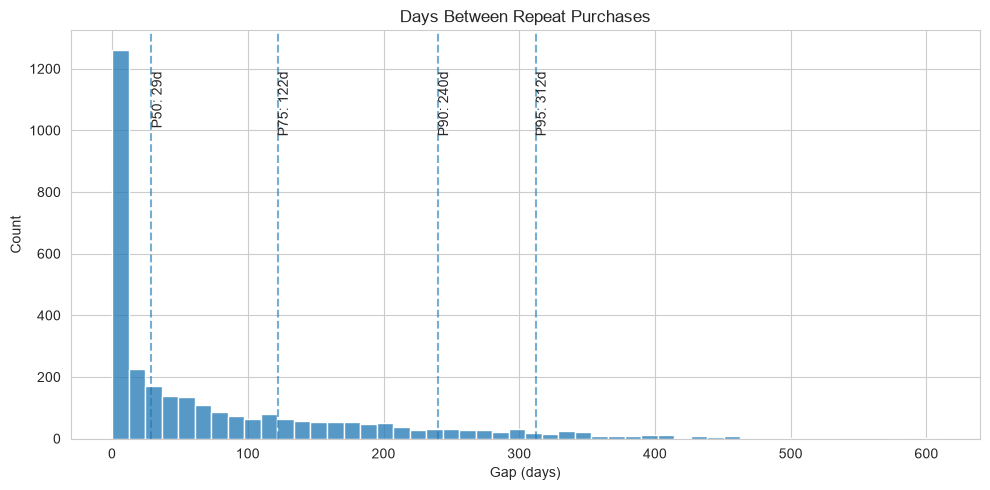

In [7]:
# Plotting the distribution of gaps, with percentile markers, so the churn
# threshold we pick in Cell 5 is visibly grounded in where the data actually
# clusters — not an arbitrary cutoff.
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(gaps["gap_days"], bins=50, ax=ax)

for pct in [50, 75, 90, 95]:
    val = np.percentile(gaps["gap_days"], pct)
    ax.axvline(val, linestyle="--", alpha=0.6)
    ax.text(val, ax.get_ylim()[1] * 0.9, f"P{pct}: {val:.0f}d", rotation=90, va="top")

ax.set_title("Days Between Repeat Purchases")
ax.set_xlabel("Gap (days)")
plt.tight_layout()
plt.savefig("../data/processed/repeat_purchase_gaps.png", dpi=150)  # save for README/writeup later
plt.show()

### Churn threshold
Using the 90th percentile as the cutoff — 90% of repeat purchases happen within 
this window, so a customer silent longer than that is unlikely to come back on 
their own.

In [8]:
# We define churn using the 90th percentile of repeat-purchase intervals.
# This captures the point by which 90% of repeat purchases have already
# occurred, making it a data-driven threshold rather than an arbitrary choice
# such as 90 or 120 days.
p90_gap = np.percentile(gaps["gap_days"], 90)
print(f"90th percentile of repeat-purchase gaps: {p90_gap:.0f} days")
print(f"→ Proposed threshold: {round(p90_gap / 30) * 30} days")

90th percentile of repeat-purchase gaps: 240 days
→ Proposed threshold: 240 days


### Checking for right-censoring
The dataset only runs through Aug 2018. Customers whose first order was recent 
have less time to prove they're not churned, labeling them off a 180-day window 
could be misleading. Checking how many customers this actually affects before 
locking in the threshold.

In [9]:
CHURN_THRESHOLD_DAYS = 180

# Last observable date in the entire dataset — our "today" for this analysis
max_date = pd.to_datetime(customer_features["last_purchase_date"]).max()
print(f"Dataset's last observed date: {max_date.date()}")

# Convert first_purchase_date to datetime for comparison
customer_features["first_purchase_date"] = pd.to_datetime(customer_features["first_purchase_date"])

# Days between a customer's FIRST purchase and the end of the dataset
customer_features["days_since_first_purchase"] = (
    max_date - customer_features["first_purchase_date"]
).dt.days

# Anyone whose first purchase was less than 180 days before the data cutoff
# hasn't had a full window to prove churn either way — flag them separately
insufficient_window = customer_features["days_since_first_purchase"] < CHURN_THRESHOLD_DAYS
n_insufficient = insufficient_window.sum()
pct_insufficient = insufficient_window.mean()

print(f"Customers with insufficient observation window: {n_insufficient:,} ({pct_insufficient:.1%})")
print(f"Customers with valid observation window: {(~insufficient_window).sum():,} ({1 - pct_insufficient:.1%})")

# Now define churn only for customers with a valid observation window
customer_features["churn_label"] = np.nan  # default: unlabeled (insufficient window)

valid_mask = ~insufficient_window
customer_features.loc[valid_mask, "churn_label"] = (
    customer_features.loc[valid_mask, "recency_days"] > CHURN_THRESHOLD_DAYS
).astype(int)

print("\nChurn label distribution (valid customers only):")
print(customer_features.loc[valid_mask, "churn_label"].value_counts(normalize=True))

Dataset's last observed date: 2018-08-29
Customers with insufficient observation window: 37,451 (40.1%)
Customers with valid observation window: 55,907 (59.9%)

Churn label distribution (valid customers only):
churn_label
1.0    0.986138
0.0    0.013862
Name: proportion, dtype: float64


### Reframing the target
With only a 3% repeat-purchase rate, a churn label built like a subscription 
business doesn't work here, because nearly everyone ends up labeled "churned," which 
teaches a model nothing. The more honest question this data supports: will a 
first-time buyer come back for a second purchase? Redefining the target around 
that instead.

In [10]:
SECOND_PURCHASE_WINDOW_DAYS = 180

# Only consider customers whose FIRST purchase had enough time to observe
# a possible second purchase within the window
customer_features["days_since_first_purchase"] = (
    max_date - customer_features["first_purchase_date"]
).dt.days

valid_cohort = customer_features["days_since_first_purchase"] >= SECOND_PURCHASE_WINDOW_DAYS
n_valid_cohort = valid_cohort.sum()
print(f"First-time buyers with a full observation window: {n_valid_cohort:,} ({valid_cohort.mean():.1%})")

# Target: did this customer place a 2nd order within the window?
# (n_orders > 1 already tells us they eventually reordered; here we're
# treating the whole dataset window as our observation period since we
# don't have per-order gap-from-first-purchase at the customer table level yet)
customer_features["made_second_purchase"] = (customer_features["n_orders"] > 1).astype(int)

target_dist = customer_features.loc[valid_cohort, "made_second_purchase"].value_counts(normalize=True)
print("\nSecond-purchase rate (valid cohort):")
print(target_dist)

First-time buyers with a full observation window: 55,907 (59.9%)

Second-purchase rate (valid cohort):
made_second_purchase
0    0.960273
1    0.039727
Name: proportion, dtype: float64


### Saving the labeled table
Locking in the valid cohort and target label here so feature engineering and 
modeling build on a clean, already-justified dataset.

In [11]:
# Keep only the valid cohort — customers with enough observation time
# to fairly judge whether they made a second purchase
labeled_customers = customer_features.loc[valid_cohort].copy()

output_path = "../data/processed/customer_features_labeled.csv"
labeled_customers.to_csv(output_path, index=False)

print(f"Saved {len(labeled_customers):,} labeled customers to {output_path}")
print(f"Target balance: {labeled_customers['made_second_purchase'].mean():.2%} positive")

Saved 55,907 labeled customers to ../data/processed/customer_features_labeled.csv
Target balance: 3.97% positive


In [12]:
labeled_customers.head()

,customer_unique_id,customer_state,n_orders,first_purchase_date,last_purchase_date,recency_days,total_spend,avg_order_value,avg_review_score,avg_delivery_delay_days,days_since_first_purchase,churn_label,made_second_purchase
0,0a0a92112bd4c708ca5fde585afaa872,RJ,1,2017-09-29 15:24:52,2017-09-29 15:24:52,334,13664.08,13664.080,1.0,-6.0,333,1.0,0
1,da122df9eeddfedc1dc1f5349a1a690c,RJ,2,2017-04-01 15:58:40,2017-04-01 15:58:41,515,7571.63,3785.815,5.0,-18.5,514,1.0,1
3,dc4802a71eae9be1dd28f5d788ceb526,MS,1,2017-02-12 20:37:36,2017-02-12 20:37:36,563,6929.31,6929.310,5.0,-6.0,562,1.0,0
5,ff4159b92c40ebe40454e3e6a7c35ed6,SP,1,2017-05-24 18:14:34,2017-05-24 18:14:34,462,6726.66,6726.660,5.0,-23.0,461,1.0,0
6,4007669dec559734d6f53e029e360987,MG,1,2017-11-24 11:03:35,2017-11-24 11:03:35,278,6081.54,6081.540,1.0,-9.0,278,1.0,0
